In [1]:
from dataclasses import dataclass, field
from typing import Any, Dict, Iterable, List, Optional, Tuple, Union, Sequence
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
from tqdm import tqdm
import wandb

In [2]:
def plot_model_metrics(df_dev, df_test, metrics=["Force", "Moment", "CoP", "Tau"]):
    """
    Plots grouped bar charts for each metric comparing dev and test results.
    
    The input DataFrames (df_dev and df_test) should contain at least the columns:
      - "model", "Force", "Moment", "CoP", and "Loss".
    
    The model names are assumed to be formatted as "BaseModel_Variant" (e.g., "FFN_BL", "FFN_CL", "FFN_CL_FT").
    This function automatically extracts:
      - base_model: the part before the underscore,
      - variant: the part after the underscore.
    
    Within each base_model group, the variants are ordered by a custom order:
      BL, then CL, then CL_FT.
      
    For each metric, two bars are shown per variant:
      - one for dev (plain fill),
      - one for test (hatched with "//").
      
    Parameters:
      df_dev (pd.DataFrame): DataFrame containing dev results.
      df_test (pd.DataFrame): DataFrame containing test results.
      metrics (list): List of metric names to plot. Defaults to ["Force", "Moment", "CoP", "Loss"].
    """
    # Work on copies to avoid modifying original data.
    df_dev = df_dev.copy()
    df_test = df_test.copy()
    
    # Extract base_model and variant from the model names.
    df_dev["base_model"] = df_dev["model"].apply(lambda x: x.split('_')[0])
    df_dev["variant"] = df_dev["model"].apply(lambda x: '_'.join(x.split('_')[1:]) if '_' in x else "")
    
    # Merge dev and test DataFrames on model so that each row has both dev and test metrics.
    df_merged = df_dev[['model','base_model','variant'] + metrics].set_index("model")
    df_test2 = df_test.set_index("model")[metrics]
    df_merged = df_merged.join(df_test2, lsuffix='_dev', rsuffix='_test').reset_index()
    
    # Define the custom variant order and corresponding color mapping.
    variant_order = {"BL": 0, "CL": 1, "CL_FT": 2}
    variant_order_list = ["BL", "CL", "CL_FT"]
    colors = {"BL": "steelblue", "CL": "seagreen", "CL_FT": "indianred"}
    
    # For each metric, produce a grouped bar plot.
    for metric in metrics:
        fig, ax = plt.subplots(figsize=(10, 3))
        
        # Get sorted base models (alphabetically)
        base_models = sorted(df_merged["base_model"].unique())
        x_positions = np.arange(len(base_models))
        
        # Set group width and calculate bar width for two bars (dev and test) per variant.
        group_width = 0.8
        n_variants = len(variant_order_list)
        bar_width = group_width / (n_variants * 2)
        
        for i, base in enumerate(base_models):
            # Get rows for the current base model and sort by our variant order.
            df_group = df_merged[df_merged["base_model"] == base].copy()
            df_group["variant_order"] = df_group["variant"].apply(lambda v: variant_order.get(v, 99))
            df_group = df_group.sort_values("variant_order")
            
            # For each expected variant (skip if not present)
            for j, variant in enumerate(variant_order_list):
                df_variant = df_group[df_group["variant"] == variant]
                if df_variant.empty:
                    continue
                # Assume one row per base/variant combination.
                value_dev = df_variant[f"{metric}_dev"].values[0]
                value_test = df_variant[f"{metric}_test"].values[0]
                # Compute horizontal offset for this variant within the group.
                offset = (j - (n_variants - 1) / 2) * (2 * bar_width)
                pos_dev = x_positions[i] + offset - bar_width / 2
                pos_test = x_positions[i] + offset + bar_width / 2
                
                # Plot dev bar (plain fill)
                ax.bar(pos_dev, value_dev, width=bar_width, color=colors[variant],
                       edgecolor='black', label=f"{variant} dev" if i==0 else "")
                # Plot test bar (with hatch pattern)
                ax.bar(pos_test, value_test, width=bar_width, color=colors[variant],
                       edgecolor='black', hatch="//", label=f"{variant} test" if i==0 else "")
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(base_models)
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} Performance by Base Model and Variant (dev vs test)")
        ax.legend()
        plt.tight_layout()
        plt.show()

# from Excel

In [3]:
def read_eval_results(filename="eval_results.xlsx"):
    """
    Reads the evaluation results from the Excel file.
    The file should have two sheets: "dev" and "test".
    Each sheet must contain columns: model, CoP, Force, Moment, Tau.
    
    Parameters:
        filename (str): Path to the Excel file.
        
    Returns:
        dev_df (pd.DataFrame): DataFrame of dev results.
        test_df (pd.DataFrame): DataFrame of test results.
    """
    dev_df = pd.read_excel(filename, sheet_name="dev")
    test_df = pd.read_excel(filename, sheet_name="test")
    
    print("[Dev DataFrame]")
    print(dev_df[["model", "CoP", "Force", "Moment", "Tau"]].round(3))
    print("\n[Test DataFrame]")
    print(test_df[["model", "CoP", "Force", "Moment", "Tau"]].round(3))
    return dev_df, test_df


In [4]:
dev_df, test_df = read_eval_results("eval_results.xlsx")
# dev_df, test_df = read_eval_results("eval_MSDegree_results.xlsx")

[Dev DataFrame]
            model    CoP  Force  Moment    Tau
0          FFN_BL  0.056  0.611   0.024  0.077
1          FFN_CL  0.022  0.615   0.024  0.072
2        Mamba_BL  0.034  0.345   0.022  0.052
3        Mamba_CL  0.019  0.345   0.022  0.052
4  Transformer_BL  0.034  0.328   0.022  0.053
5  Transformer_CL  0.020  0.326   0.022  0.055

[Test DataFrame]
            model    CoP  Force  Moment    Tau
0          FFN_BL  0.075  1.119   0.247  0.141
1          FFN_CL  0.038  1.121   0.246  0.142
2        Mamba_BL  0.057  0.844   0.244  0.121
3        Mamba_CL  0.033  0.806   0.244  0.120
4  Transformer_BL  0.057  0.804   0.245  0.119
5  Transformer_CL  0.034  0.752   0.243  0.121


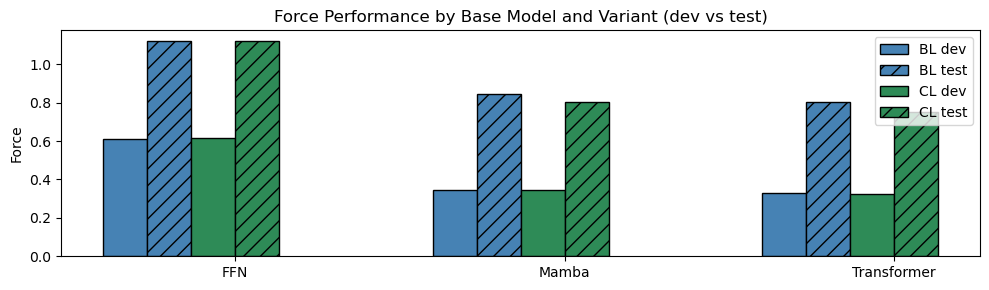

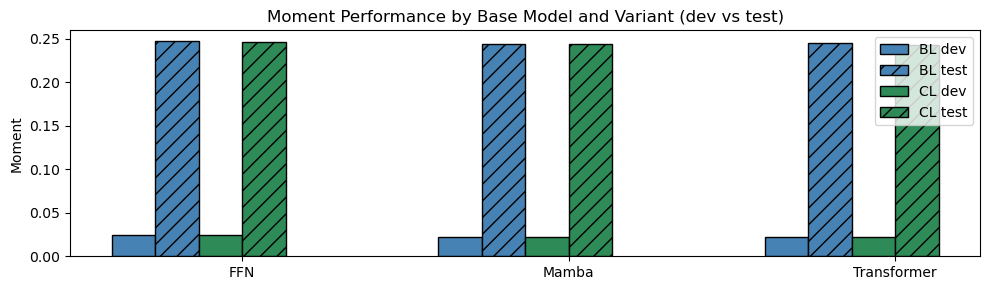

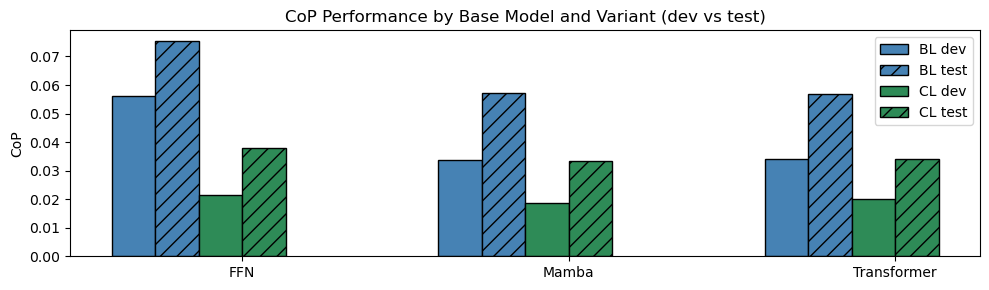

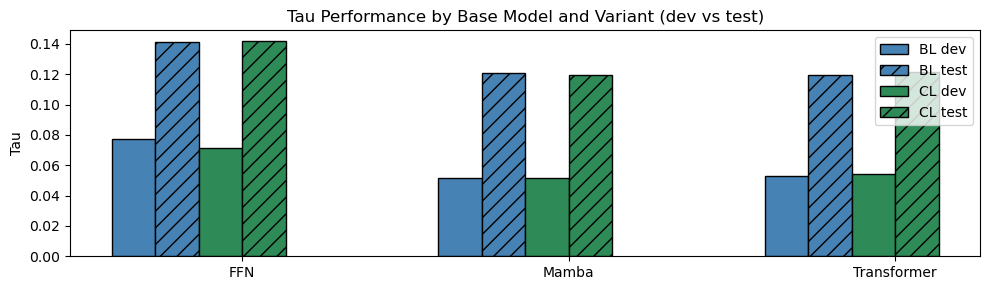

In [5]:
plot_model_metrics(dev_df, test_df)

# from WandB

In [6]:
class WandBFetcher:
    """data loader for WandB runs."""
    def __init__(self, project_path: str, scan_rows: int = 10):
        self.api = wandb.Api()
        self.project_path = project_path
        self.scan_rows = scan_rows

    def _scan_keys(self, run) -> set:
        keys = set()
        for i, row in enumerate(run.scan_history()):
            keys.update(row.keys())
            if i + 1 >= self.scan_rows:
                break
        return keys

    @staticmethod
    def _find_episode_key(keys: Sequence[str]) -> Optional[str]:
        pref = ['Episode', 'episode', 'Episodes', '_step', 'step', 'global_step']
        cand = [k for k in keys if ('episode' in k.lower()) or k in {'_step','step','global_step'}]
        for p in pref:
            if p in cand:
                return p
        return cand[0] if cand else None
    
    def fetch_best_dev_test(
        self,
        run,
        dev_metric: List[str],
        test_metric: List[str],
        loss_key: str = "dev/reports/Loss (Norm Err)",
        samples: int = 100000
    ) -> Dict[str, pd.Series] | None:
        model_name = run.id.rsplit('_', 1)[0]
        dev_loss_df = run.history(samples=samples, keys=[loss_key], x_axis='dev/step')
        idx_min = dev_loss_df[loss_key].idxmin()

        dev_df = run.history(samples=samples, keys=dev_metric, x_axis='dev/step')
        dev_row = dev_df.loc[idx_min]

        test_df = run.history(samples=samples, keys=test_metric, x_axis='test/step')
        test_row = test_df.loc[idx_min]

        return model_name, dev_row, test_row
    
    def get_run(self, run_id: str = None) -> Optional[wandb.apis.public.Run]:
        if run_id is None:
            """Fetch all runs in the project."""
            return self.api.runs(self.project_path)
        else:
            """Fetch a specific run by ID."""
            try:
                return self.api.run(f"{self.project_path}/{run_id}")
            except Exception as e:
                print(f"[error] load {run_id}: {e}")
                return None


In [7]:
PROJECT_PATH   = "jojaebeom/CoPLimiter"
fetcher = WandBFetcher(PROJECT_PATH)

In [8]:
DEV_METRIC = [
    'dev/reports/CoP Err (m)',
    'dev/reports/Force Err (N per kg)',
    'dev/reports/Moment Err (Nm per kg)',
    # 'dev/reports/Non-root Joint Torques (Inverse Dynamics) Err (Nm per kg)'
]
TEST_METRIC = [
    'test/reports/CoP Err (m)',
    'test/reports/Force Err (N per kg)',
    'test/reports/Moment Err (Nm per kg)',
    # 'test/reports/Non-root Joint Torques (Inverse Dynamics) Err (Nm per kg)'
]
# SHORT_COLS = ['CoP', 'Force', 'Moment', 'Tau']
SHORT_COLS = ['CoP', 'Force', 'Moment']
DEV_MAP   = dict(zip(DEV_METRIC,  SHORT_COLS))
TEST_MAP  = dict(zip(TEST_METRIC, SHORT_COLS))

In [9]:
all_runs = fetcher.get_run()
dev_rows, test_rows = [], []

for run in all_runs:
    print(f"Run: {run.name}")
    model, dev_row, test_row = fetcher.fetch_best_dev_test(run, DEV_METRIC, TEST_METRIC)

    dev_rows.append({
        "model": model,
        **{short: dev_row[full] for full, short in DEV_MAP.items()}
    })

    test_rows.append({
        "model": model,
        **{short: test_row[full] for full, short in TEST_MAP.items()}
    })

dev_df  = pd.DataFrame(dev_rows).sort_values("model")
test_df = pd.DataFrame(test_rows).sort_values("model")

Run: Transformer_CL_20250306-132150
Run: Transformer_BL_20250306-144859
Run: FFN_BL_20250307-001904
Run: Mamba_BL_20250307-090321
Run: Mamba_CL_20250307-090835
Run: FFN_CL_20250307-171813
Run: STMamba_BL_20250307-190449
Run: STMamba_CL_20250308-115856
Run: Mamba_CL_FT_20250317-165110
Run: Transformer_CL_FT_20250318-093025
Run: STMamba_CL_FT_20250319-125051
Run: FFN_CL_FT_20250320-161421


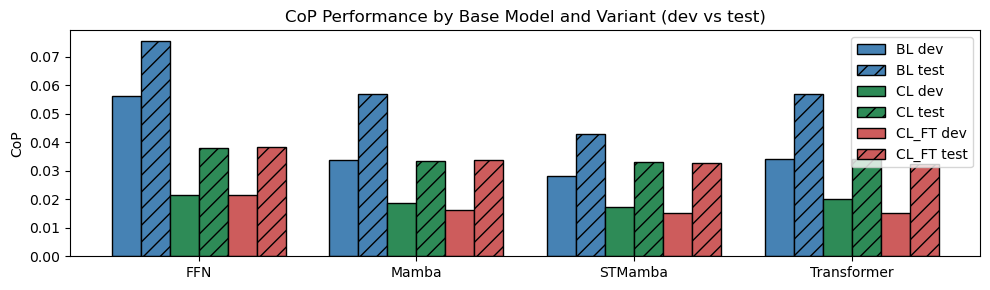

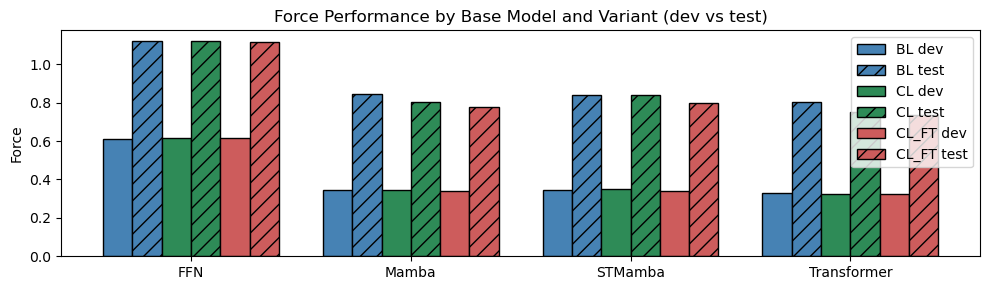

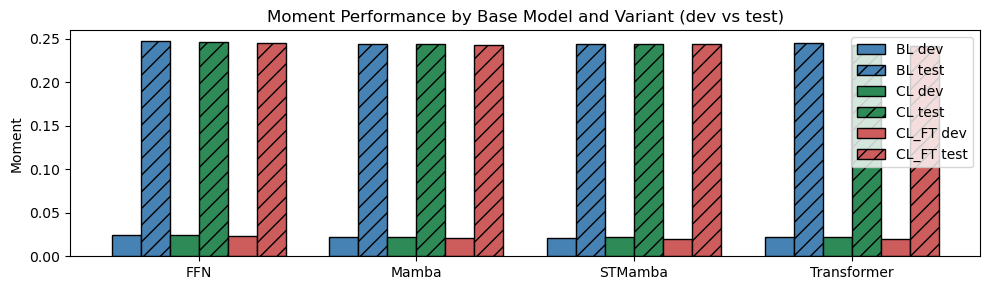

In [10]:
plot_model_metrics(dev_df, test_df, SHORT_COLS)